# Cookie Cats A/B Test: Gate at Level 30 vs Level 40

Does moving the first gate from level 30 to level 40 change player retention?

The pre-registered analysis plan is in [`docs/analysis_plan.md`](../docs/analysis_plan.md).
The data comes from [Kaggle](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) and is not included in this repo. Place `cookie_cats.csv` in `data/`.

## 1. Data loading and exploration

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Works whether the notebook is started from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

df = pd.read_csv(ROOT / "data" / "cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
print(df.shape)
print()
print(df.dtypes)
print()
print("Missing values:\n", df.isna().sum())
print()
print("Duplicate userids:", df["userid"].duplicated().sum())
print()
print(df["version"].value_counts())

(90189, 5)

userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object

Missing values:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate userids: 0

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [3]:
print(df["sum_gamerounds"].describe())
print()
print(df["sum_gamerounds"].quantile([0.5, 0.9, 0.99, 0.999]))
print()
print("Players with 0 rounds:", (df["sum_gamerounds"] == 0).sum())
print()
df.nlargest(5, "sum_gamerounds")

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

0.500      16.000
0.900     134.000
0.990     493.000
0.999    1073.624
Name: sum_gamerounds, dtype: float64

Players with 0 rounds: 3994



,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


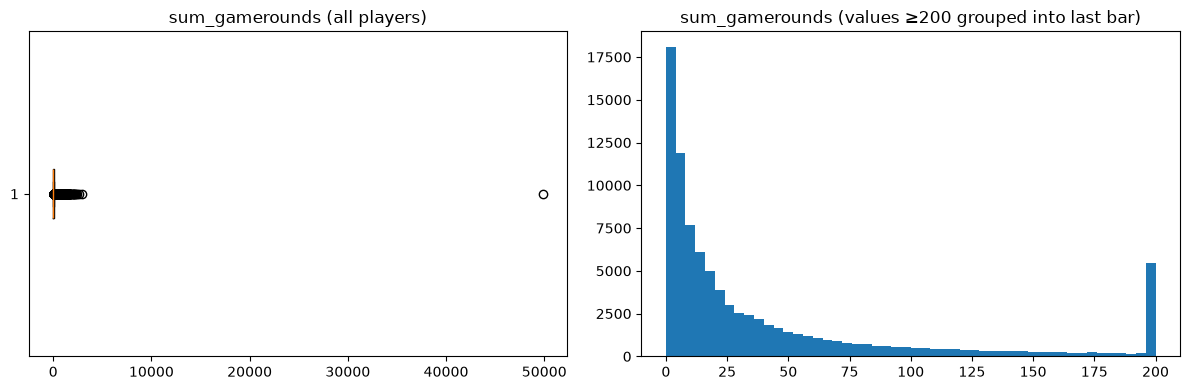

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["sum_gamerounds"], orientation="horizontal")
axes[0].set_title("sum_gamerounds (all players)")
axes[1].hist(df["sum_gamerounds"].clip(upper=200), bins=50)
axes[1].set_title("sum_gamerounds (values ≥200 grouped into last bar)")
plt.tight_layout()
plt.show()

## Exploration notes
- 90,189 players, no missing values, no duplicate userids.
- Groups: gate_30 = 44,700, gate_40 = 45,489.
- sum_gamerounds is right-skewed (median 16, mean 51.9, 99th pct 493).
- One extreme outlier (49,854 rounds, next highest 2,961), likely a logging error.
- 3,994 players played 0 rounds; kept because they were randomised.
- Retention by group NOT examined yet: the analysis plan (docs/analysis_plan.md) was committed first.

## 2. Sample ratio mismatch (SRM) check

Players were supposed to be split 50/50 between the two versions. If the actual split differs by more than chance can explain, the randomisation or data pipeline may be broken, and any difference in retention could come from *who ended up in each group* rather than from the gate.

The pre-registered threshold is **p < 0.01**.

In [5]:
from ab_stats import srm_check
from plot_style import COLORS, INK_MUTED, apply_style

apply_style()

counts = df["version"].value_counts().sort_index()
srm = srm_check(counts.values)
print(counts.to_string())
print(f"\nExpected per group under 50/50: {srm['expected'][0]:,.1f}")
print(f"Chi-square = {srm['chi2']:.3f}, p-value = {srm['p_value']:.4f}")
print("SRM detected (p < 0.01)" if srm["p_value"] < 0.01 else "No SRM (p >= 0.01)")

version
gate_30    44700
gate_40    45489

Expected per group under 50/50: 45,094.5
Chi-square = 6.902, p-value = 0.0086
SRM detected (p < 0.01)


### Investigating the mismatch

The plan says: if SRM is detected, investigate what the data allows and document what we find. We have no assignment logs, so we can only check the following:

1. **Duplicate users.** Already checked: 0 duplicate `userid`s.
2. **Is the imbalance spread evenly across the user-ID range, or concentrated in one block?** A concentrated imbalance would point to something like a bug in one batch of IDs.
3. **Is the imbalance among players who could never have seen a gate?** To reach the gate at level 30, a player must complete levels 1–29, which is at least 29 rounds. A player with fewer than 29 rounds never met a gate in *either* version, so the treatment cannot have changed whether they are in that group. Their numbers should be 50/50 if assignment worked.

Note: these are exploratory checks, not pre-registered tests.

In [6]:
# 2. Imbalance across the user-ID range (10 equal-size bands)
id_band = pd.qcut(df["userid"], 10, labels=[f"D{i}" for i in range(1, 11)])
by_band = pd.crosstab(id_band, df["version"])
by_band["share_gate_40"] = (by_band["gate_40"] / by_band.sum(axis=1)).round(4)
print(by_band)

from scipy import stats
chi2_band, p_band, _, _ = stats.chi2_contingency(pd.crosstab(id_band, df["version"]))
print(f"\nDoes the split differ between ID bands? chi-square = {chi2_band:.2f}, p = {p_band:.3f}")

version  gate_30  gate_40  share_gate_40
userid                                  
D1          4474     4545         0.5039
D2          4486     4533         0.5026
D3          4507     4512         0.5003
D4          4542     4477         0.4964
D5          4391     4628         0.5131
D6          4471     4547         0.5042
D7          4487     4532         0.5025
D8          4474     4545         0.5039
D9          4450     4569         0.5066
D10         4418     4601         0.5101

Does the split differ between ID bands? chi-square = 7.31, p = 0.605


In [7]:
# 3. Players who never reached a gate (< 29 rounds) vs players who could have (>= 29 rounds)
GATE_ROUNDS = 29
df["could_reach_gate"] = np.where(df["sum_gamerounds"] >= GATE_ROUNDS, ">= 29 rounds", "< 29 rounds")

srm_rows = []
for segment, seg_df in df.groupby("could_reach_gate"):
    seg_counts = seg_df["version"].value_counts().sort_index()
    res = srm_check(seg_counts.values)
    srm_rows.append({
        "segment": segment,
        "gate_30": seg_counts["gate_30"],
        "gate_40": seg_counts["gate_40"],
        "share_gate_40": round(seg_counts["gate_40"] / seg_counts.sum(), 4),
        "srm_p_value": round(res["p_value"], 4),
    })
srm_segments = pd.DataFrame(srm_rows)
srm_segments

,segment,gate_30,gate_40,share_gate_40,srm_p_value
0,< 29 rounds,27742,28565,0.5073,0.0005
1,>= 29 rounds,16958,16924,0.4995,0.8535


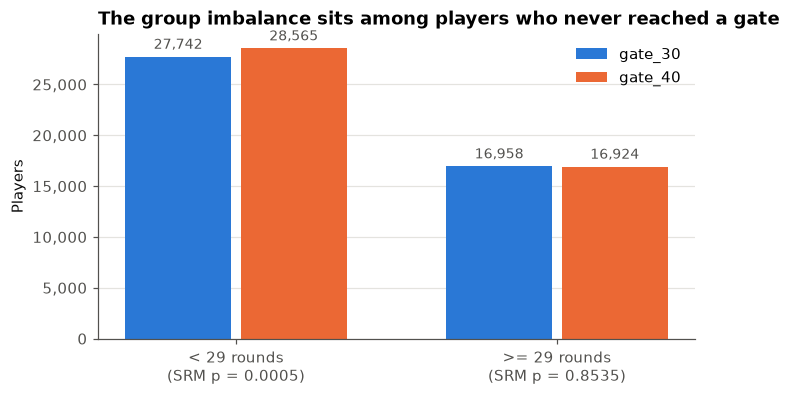

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(len(srm_segments))
width = 0.36
for i, group in enumerate(["gate_30", "gate_40"]):
    bars = ax.bar(x + (i - 0.5) * width, srm_segments[group], width - 0.03,
                  color=COLORS[group], label=group)
    ax.bar_label(bars, labels=[f"{v:,}" for v in srm_segments[group]],
                 padding=3, fontsize=9, color=INK_MUTED)
ax.set_xticks(x, [f"{s}\n(SRM p = {p:.4f})" for s, p in zip(srm_segments["segment"], srm_segments["srm_p_value"])])
ax.set_ylabel("Players")
ax.set_title("The group imbalance sits among players who never reached a gate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
fig.savefig(RESULTS / "srm_by_engagement.png")
plt.show()

### SRM findings

- **SRM is detected.** gate_40 has 789 more players than gate_30 (45,489 vs 44,700), and the chi-square p-value of about 0.009 is below the pre-registered 0.01 threshold.
- **No duplicate users**, and the imbalance is **spread evenly across the user-ID range**, with no difference between ID bands. That argues against a bug in one batch of IDs.
- **The whole imbalance sits among players with fewer than 29 rounds**, who never saw a gate. Among players who could have reached the gate, the groups are almost exactly equal.
- The gate can't have caused this. These players never met it, so either (a) it's an unlucky chance result, or (b) some data-collection or assignment issue affected low-engagement players, for example some gate_30 low-engagement players missing from the export. **We can't tell which from this dataset.**
- **Why it matters for the results:** low-engagement players rarely come back. If gate_40 has *extra* low-engagement players, gate_40's retention could look slightly worse than it really is.

**What we do, following the plan:**
1. Report the main results as **exploratory, with the SRM caveat** attached.
2. As an extra sensitivity check, repeat the main test on players with ≥ 29 rounds, where the groups are balanced. Whether a player reached 29 rounds is decided *before* any gate, so this split doesn't break randomisation. That's different from adjusting for total rounds (see section 6).
3. Recommend that the team checks the assignment and logging pipeline before any decision is final.

## 3. Main results: does the gate position change retention?

Following the plan:
- a **two-proportion z-test** for each retention metric, with a 95% confidence interval for the difference (gate_40 − gate_30)
- **absolute lift**, in percentage points, and **relative lift**, as % of the control rate
- **Holm correction** across the two metrics
- a **bootstrap** as a second, assumption-light method

Because SRM was detected (section 2), these results are reported as **exploratory**, with the SRM caveat.

In [9]:
from ab_stats import bootstrap_diff, compare_proportions
from statsmodels.stats.multitest import multipletests

METRICS = ["retention_7", "retention_1"]  # primary first
control = df[df["version"] == "gate_30"]
treatment = df[df["version"] == "gate_40"]


def run_tests(data, metrics=METRICS):
    rows = []
    for metric in metrics:
        c = data.loc[data["version"] == "gate_30", metric]
        t = data.loc[data["version"] == "gate_40", metric]
        res = compare_proportions([c.sum(), t.sum()], [len(c), len(t)])
        rows.append({"metric": metric, "n_control": len(c), "n_treatment": len(t), **res})
    return pd.DataFrame(rows)


results = run_tests(df)
reject, p_holm, _, _ = multipletests(results["p_value"], alpha=0.05, method="holm")
results["p_holm"] = p_holm
results["significant_after_holm"] = reject

show = results.copy()
for col in ["rate_control", "rate_treatment", "abs_lift", "ci_low", "ci_high", "rel_lift", "rel_ci_low", "rel_ci_high"]:
    show[col] = (show[col] * 100).round(2)
show[["metric", "n_control", "n_treatment", "rate_control", "rate_treatment",
      "abs_lift", "ci_low", "ci_high", "rel_lift", "p_value", "p_holm", "significant_after_holm"]]

,metric,n_control,n_treatment,rate_control,rate_treatment,abs_lift,ci_low,ci_high,rel_lift,p_value,p_holm,significant_after_holm
0,retention_7,44700,45489,19.02,18.20,-0.82,-1.33,-0.31,-4.31,0.001554,0.003108,True
1,retention_1,44700,45489,44.82,44.23,-0.59,-1.24,0.06,-1.32,0.074410,0.074410,False


The rates, lifts and CIs above are in **%**. `abs_lift`, `ci_low` and `ci_high` are in **percentage points**.

### Bootstrap check
We resample players with replacement within each group 10,000 times and recompute the difference each time. The middle 95% of those differences is the bootstrap confidence interval. If it matches the z-test interval, the normal approximation behind the z-test is fine.

In [10]:
boot = {m: bootstrap_diff(control[m], treatment[m], n_boot=10_000, seed=42) for m in METRICS}
comparison = pd.DataFrame({
    "metric": METRICS,
    "z_test_ci_low": [results.set_index("metric").loc[m, "ci_low"] * 100 for m in METRICS],
    "z_test_ci_high": [results.set_index("metric").loc[m, "ci_high"] * 100 for m in METRICS],
    "bootstrap_ci_low": [boot[m]["ci_low"] * 100 for m in METRICS],
    "bootstrap_ci_high": [boot[m]["ci_high"] * 100 for m in METRICS],
}).round(2)
comparison

,metric,z_test_ci_low,z_test_ci_high,bootstrap_ci_low,bootstrap_ci_high
0,retention_7,-1.33,-0.31,-1.34,-0.31
1,retention_1,-1.24,0.06,-1.25,0.06


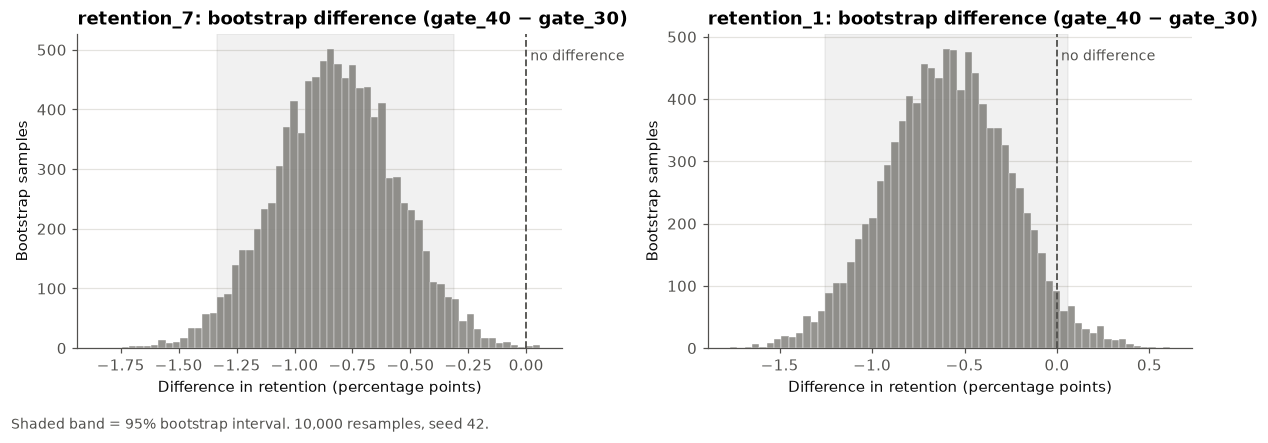

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, metric in zip(axes, METRICS):
    diffs = boot[metric]["diffs"] * 100
    ax.hist(diffs, bins=60, color="#8a8984", alpha=0.9, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color=INK_MUTED, linewidth=1.2, linestyle="--")
    ax.axvspan(boot[metric]["ci_low"] * 100, boot[metric]["ci_high"] * 100, color=INK_MUTED, alpha=0.08)
    ax.text(0, ax.get_ylim()[1] * 0.95, " no difference", color=INK_MUTED, fontsize=9, va="top")
    ax.set_title(f"{metric}: bootstrap difference (gate_40 − gate_30)")
    ax.set_xlabel("Difference in retention (percentage points)")
    ax.set_ylabel("Bootstrap samples")
    ax.grid(axis="x", visible=False)
fig.text(0.01, -0.04, "Shaded band = 95% bootstrap interval. 10,000 resamples, seed 42.", color=INK_MUTED, fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS / "bootstrap_distributions.png")
plt.show()

### Retention by group

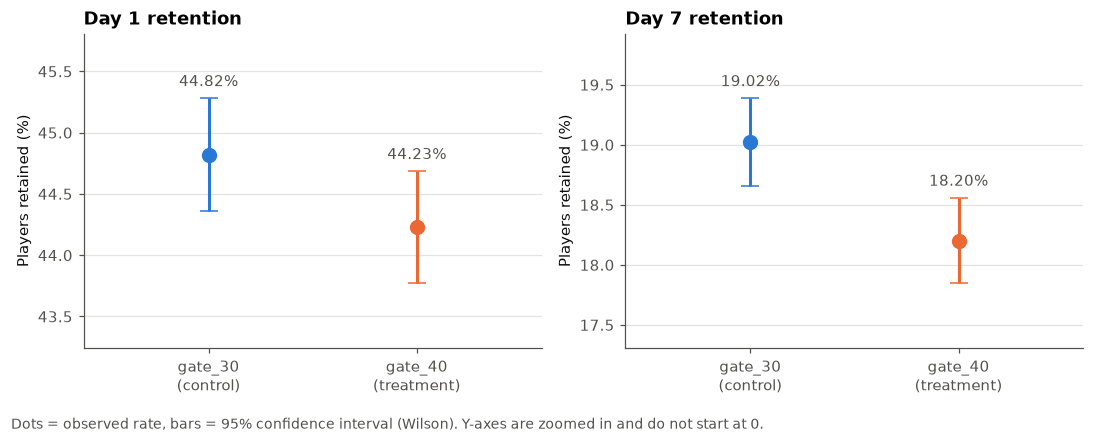

In [12]:
from statsmodels.stats.proportion import proportion_confint

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, metric in zip(axes, ["retention_1", "retention_7"]):
    for i, group in enumerate(["gate_30", "gate_40"]):
        s = df.loc[df["version"] == group, metric]
        rate = s.mean() * 100
        lo, hi = (np.array(proportion_confint(s.sum(), len(s), method="wilson")) * 100)
        ax.errorbar(i, rate, yerr=[[rate - lo], [hi - rate]], fmt="o", color=COLORS[group],
                    markersize=9, capsize=6, elinewidth=2)
        ax.annotate(f"{rate:.2f}%", (i, hi), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=10, color=INK_MUTED)
    ax.set_xticks([0, 1], ["gate_30\n(control)", "gate_40\n(treatment)"])
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel("Players retained (%)")
    ax.set_title(f"{metric.replace('_', ' ').replace('retention', 'Day')} retention")
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.35)
fig.text(0.01, -0.04, "Dots = observed rate, bars = 95% confidence interval (Wilson). Y-axes are zoomed in and do not start at 0.",
         color=INK_MUTED, fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS / "retention_by_group.png")
plt.show()

### Sensitivity checks (exploratory)

1. **Without the extreme outlier** (49,854 rounds). This one was pre-registered.
2. **Only players with ≥ 29 rounds.** These are the players who could reach a gate, and the groups here are balanced (no SRM, section 2). Whether a player reached 29 rounds is decided before any gate, so this split doesn't break randomisation.
3. **Placebo check: only players with < 29 rounds.** They never saw a gate, so the true effect for them must be zero. A clear difference here would suggest the SRM is biasing the comparison.

In [13]:
outlier_id = df.loc[df["sum_gamerounds"].idxmax(), "userid"]
sensitivity = pd.concat([
    run_tests(df).assign(analysis="All players (main)"),
    run_tests(df[df["userid"] != outlier_id]).assign(analysis="Without outlier"),
    run_tests(df[df["sum_gamerounds"] >= GATE_ROUNDS]).assign(analysis=">= 29 rounds (balanced groups)"),
    run_tests(df[df["sum_gamerounds"] < GATE_ROUNDS]).assign(analysis="< 29 rounds (placebo)"),
], ignore_index=True)

sens_show = sensitivity[["analysis", "metric", "n_control", "n_treatment", "rate_control", "rate_treatment",
                         "abs_lift", "ci_low", "ci_high", "p_value"]].copy()
for col in ["rate_control", "rate_treatment", "abs_lift", "ci_low", "ci_high"]:
    sens_show[col] = (sens_show[col] * 100).round(2)
sens_show["p_value"] = sens_show["p_value"].round(4)
sens_show

,analysis,metric,n_control,n_treatment,rate_control,rate_treatment,abs_lift,ci_low,ci_high,p_value
0,All players (main),retention_7,44700,45489,19.02,18.20,-0.82,-1.33,-0.31,0.0016
1,All players (main),retention_1,44700,45489,44.82,44.23,-0.59,-1.24,0.06,0.0744
2,Without outlier,retention_7,44699,45489,19.02,18.20,-0.82,-1.33,-0.31,0.0016
3,Without outlier,retention_1,44699,45489,44.82,44.23,-0.59,-1.24,0.06,0.0739
4,>= 29 rounds (balanced groups),retention_7,16958,16924,43.40,42.43,-0.97,-2.02,0.08,0.0711
5,>= 29 rounds (balanced groups),retention_1,16958,16924,79.71,79.92,0.20,-0.65,1.06,0.6440
6,< 29 rounds (placebo),retention_7,27742,28565,4.12,3.84,-0.27,-0.60,0.05,0.0980
7,< 29 rounds (placebo),retention_1,27742,28565,23.49,23.08,-0.40,-1.10,0.29,0.2572


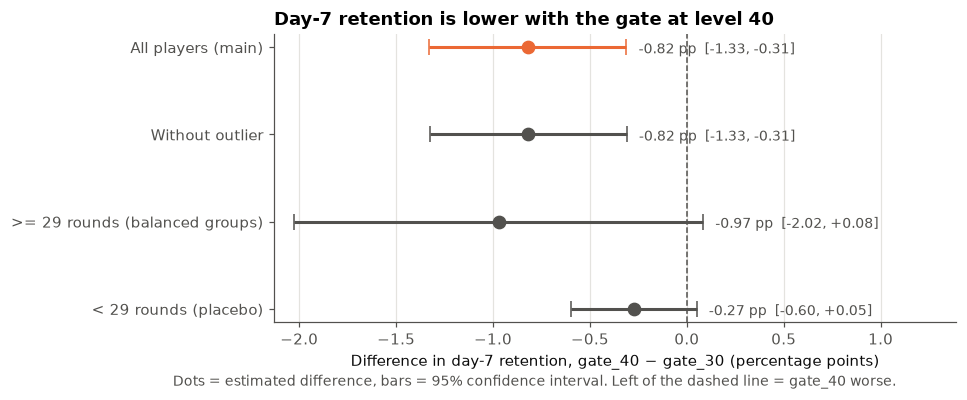

In [14]:
plot_df = sensitivity[sensitivity["metric"] == "retention_7"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 3.4))
y = np.arange(len(plot_df))[::-1]
for yi, (_, row) in zip(y, plot_df.iterrows()):
    main = row["analysis"] == "All players (main)"
    color = COLORS["gate_40"] if main else INK_MUTED
    ax.errorbar(row["abs_lift"] * 100, yi,
                xerr=[[(row["abs_lift"] - row["ci_low"]) * 100], [(row["ci_high"] - row["abs_lift"]) * 100]],
                fmt="o", color=color, markersize=8, capsize=5, elinewidth=2)
    ax.annotate(f"{row['abs_lift'] * 100:+.2f} pp  [{row['ci_low'] * 100:+.2f}, {row['ci_high'] * 100:+.2f}]",
                (row["ci_high"] * 100, yi), textcoords="offset points", xytext=(8, -4), fontsize=9, color=INK_MUTED)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_yticks(y, plot_df["analysis"])
ax.set_xlabel("Difference in day-7 retention, gate_40 − gate_30 (percentage points)")
ax.set_title("Day-7 retention is lower with the gate at level 40")
ax.grid(axis="y", visible=False)
ax.set_xlim(right=ax.get_xlim()[1] + 1.2)
fig.text(0.01, -0.06, "Dots = estimated difference, bars = 95% confidence interval. Left of the dashed line = gate_40 worse.",
         color=INK_MUTED, fontsize=9)
fig.savefig(RESULTS / "retention7_lift_sensitivity.png")
plt.show()

### What the main results say

| Metric | gate_30 | gate_40 | Absolute lift (95% CI) | Relative lift | p (Holm) |
|---|---|---|---|---|---|
| **Day-7 retention (primary)** | 19.02% | 18.20% | **−0.82 pp** [−1.33, −0.31] | −4.3% | **0.003** ✔ significant |
| Day-1 retention (secondary) | 44.82% | 44.23% | −0.59 pp [−1.24, +0.06] | −1.3% | 0.074 ✘ not significant |

- **Day-7 retention is lower with the gate at level 40.** For every 1,000 players, about 8 fewer are still playing a week after install. The confidence interval is entirely below zero, and the result stays significant after the Holm correction.
- **Day-1 retention shows no significant difference.** That's expected, because most players haven't reached level 30 on day 1.
- **The bootstrap agrees with the z-test** to within 0.01 pp, so the normal approximation holds with ~45k players per group.
- **Sensitivity:**
  - Removing the outlier changes nothing.
  - Among players who could reach a gate (balanced groups), the day-7 drop is similar in size (−0.97 pp). The interval just touches zero [−2.02, +0.08] because this subgroup is only about a third of the players.
  - The placebo group (never saw a gate) shows a small, non-significant difference (−0.27 pp, p = 0.10). The SRM may add a little noise, but it doesn't explain the main effect away.

**Decision under the plan:** gate_40 has *significantly lower* day-7 retention, so **keep the gate at level 30**. Because SRM was detected, this is reported as exploratory: the direction is consistent across every check, but the data pipeline should be checked before the result is treated as final.

## 4. Power: how small an effect could this test detect?

**Power** is the probability that the test flags a difference when a real difference of a given size exists. The **minimum detectable effect (MDE)** is the smallest true difference we would catch 80% of the time with this sample size (α = 0.05, two-sided).

MDE = (z₀.₉₇₅ + z₀.₈₀) × √( p(1−p) × (1/n₁ + 1/n₂) ), where p is the control's retention rate.

We don't report "observed power", meaning power calculated at the effect we happened to observe. It's just a restatement of the p-value and adds no information.

In [15]:
from ab_stats import minimum_detectable_effect, power_for_effect
from statsmodels.stats.power import NormalIndPower

mde_rows = []
for label, data, metric in [
    ("All players", df, "retention_7"),
    ("All players", df, "retention_1"),
    (">= 29 rounds", df[df["sum_gamerounds"] >= GATE_ROUNDS], "retention_7"),
]:
    c = data.loc[data["version"] == "gate_30", metric]
    t = data.loc[data["version"] == "gate_40", metric]
    base = c.mean()
    observed = t.mean() - base
    for alpha in [0.05, 0.025]:
        mde = minimum_detectable_effect(base, len(c), len(t), alpha=alpha)
        mde_rows.append({
            "population": label, "metric": metric, "alpha": alpha,
            "baseline_rate_%": round(base * 100, 2),
            "mde_pp": round(mde * 100, 2),
            "mde_relative_%": round(mde / base * 100, 2),
            "observed_diff_pp": round(observed * 100, 2),
        })
mde_table = pd.DataFrame(mde_rows)
mde_table

,population,metric,alpha,baseline_rate_%,mde_pp,mde_relative_%,observed_diff_pp
0,All players,retention_7,0.050,19.02,0.73,3.85,-0.82
1,All players,retention_7,0.025,19.02,0.81,4.24,-0.82
2,All players,retention_1,0.050,44.82,0.93,2.07,-0.59
3,All players,retention_1,0.025,44.82,1.02,2.28,-0.59
4,>= 29 rounds,retention_7,0.050,43.40,1.51,3.48,-0.97
5,>= 29 rounds,retention_7,0.025,43.40,1.66,3.83,-0.97


In [16]:
# Cross-check the formula with statsmodels (Cohen's h effect size, converted back to percentage points)
p7 = control["retention_7"].mean()
h = NormalIndPower().solve_power(nobs1=len(control), ratio=len(treatment) / len(control), alpha=0.05, power=0.80)
print(f"statsmodels MDE for retention_7 ≈ {h * np.sqrt(p7 * (1 - p7)) * 100:.2f} pp  "
      f"(formula: {minimum_detectable_effect(p7, len(control), len(treatment)) * 100:.2f} pp)")

statsmodels MDE for retention_7 ≈ 0.73 pp  (formula: 0.73 pp)


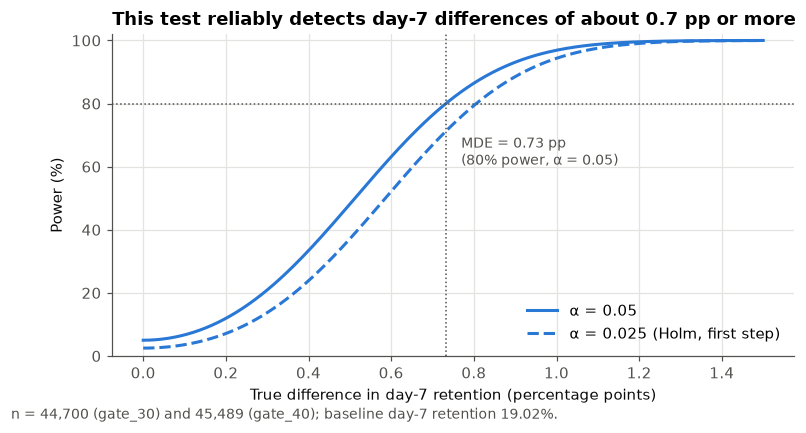

In [17]:
effects = np.linspace(0, 0.015, 200)
fig, ax = plt.subplots(figsize=(8, 3.8))
for label, alpha, style in [("α = 0.05", 0.05, "-"), ("α = 0.025 (Holm, first step)", 0.025, "--")]:
    ax.plot(effects * 100, power_for_effect(effects, p7, len(control), len(treatment), alpha=alpha) * 100,
            color=COLORS["gate_30"], linewidth=2, linestyle=style, label=label)
mde7 = minimum_detectable_effect(p7, len(control), len(treatment))
ax.axhline(80, color=INK_MUTED, linewidth=1, linestyle=":")
ax.axvline(mde7 * 100, color=INK_MUTED, linewidth=1, linestyle=":")
ax.annotate(f"MDE = {mde7 * 100:.2f} pp\n(80% power, α = 0.05)", (mde7 * 100, 80), textcoords="offset points",
            xytext=(10, -40), fontsize=9, color=INK_MUTED)
ax.set_xlabel("True difference in day-7 retention (percentage points)")
ax.set_ylabel("Power (%)")
ax.set_ylim(0, 102)
ax.set_title("This test reliably detects day-7 differences of about 0.7 pp or more")
ax.legend(loc="lower right")
fig.text(0.01, -0.04, f"n = {len(control):,} (gate_30) and {len(treatment):,} (gate_40); baseline day-7 retention {p7 * 100:.2f}%.",
         color=INK_MUTED, fontsize=9)
fig.savefig(RESULTS / "power_curve_retention7.png")
plt.show()

### What power means for our conclusion

- **Day-7 retention:** with ~45k players per group, the test detects a true difference of **0.73 pp** (3.9% relative) 80% of the time, or 0.81 pp at Holm's stricter first-step α = 0.025. The observed −0.82 pp is right at that size, so the experiment was large enough to pick up an effect this big. A smaller true effect, say 0.3 pp, would often go unnoticed.
- **Day-1 retention:** the MDE is **0.93 pp**, and the observed difference (−0.59 pp) is smaller than that. So "not significant" here means *"the data is consistent with anything from a 1.24 pp drop to a 0.06 pp gain (the 95% CI)"*, not "the gate has no effect on day 1".
- **Players with ≥ 29 rounds:** the MDE roughly doubles to **1.51 pp** because the subgroup is a third of the size. That's why its confidence interval was wide and touched zero, even though its point estimate (−0.97 pp) is close to the main result.

## 5. The post-treatment trap: why we don't adjust for `sum_gamerounds`

It's tempting to "control for" how much people played, because game rounds strongly predict retention. But `sum_gamerounds` is measured **after** the gate was assigned, and **the gate itself changes it**. Adjusting for a variable that the treatment affects breaks the randomisation.

**Step 1: show that the gate changes how much people play.** We look at players with ≥ 29 rounds. They're the only ones who could meet a gate, and the groups are balanced there (section 2). If the gate had no effect on play, both groups would spread across round bands in the same way.

In [18]:
reached = df[df["sum_gamerounds"] >= GATE_ROUNDS].copy()
reached["rounds_band"] = pd.cut(reached["sum_gamerounds"], bins=[29, 40, 60, np.inf], right=False,
                                labels=["29-39", "40-59", "60+"])
band_counts = pd.crosstab(reached["rounds_band"], reached["version"])
band_share = (band_counts / band_counts.sum() * 100).round(2)
chi2_bands, p_bands, _, _ = stats.chi2_contingency(band_counts)
print(band_counts, "\n")
print("Share of each group (%):\n", band_share, "\n")
print(f"Does the gate change the distribution of rounds? chi-square = {chi2_bands:.1f}, p = {p_bands:.2g}")

version      gate_30  gate_40
rounds_band                  
29-39           3392     3097
40-59           3804     3650
60+             9762    10177 

Share of each group (%):
 version      gate_30  gate_40
rounds_band                  
29-39          20.00    18.30
40-59          22.43    21.57
60+            57.57    60.13 

Does the gate change the distribution of rounds? chi-square = 25.2, p = 3.4e-06


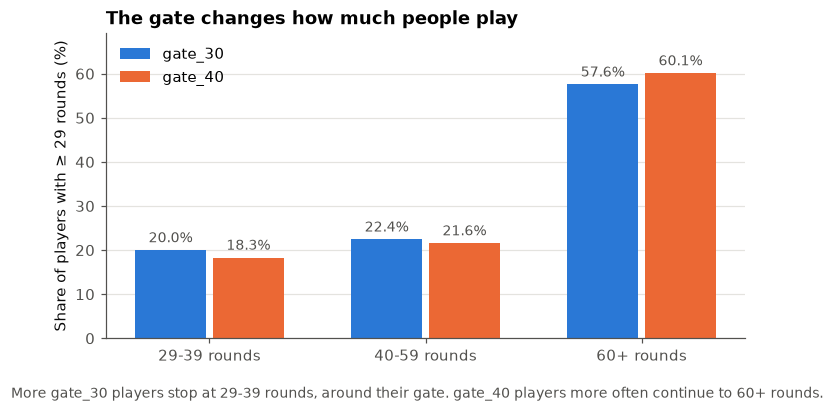

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = np.arange(len(band_share))
width = 0.36
for i, group in enumerate(["gate_30", "gate_40"]):
    bars = ax.bar(x + (i - 0.5) * width, band_share[group], width - 0.03, color=COLORS[group], label=group)
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in band_share[group]], padding=3, fontsize=9, color=INK_MUTED)
ax.set_xticks(x, [f"{b} rounds" for b in band_share.index])
ax.set_ylabel("Share of players with ≥ 29 rounds (%)")
ax.set_title("The gate changes how much people play")
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
ax.margins(y=0.15)
fig.text(0.01, -0.04, "More gate_30 players stop at 29-39 rounds, around their gate. gate_40 players more often continue to 60+ rounds.",
         color=INK_MUTED, fontsize=9)
fig.savefig(RESULTS / "gate_changes_gamerounds.png")
plt.show()

**Step 2: what an "adjusted" estimate looks like.** We fit a linear probability model (OLS on the 0/1 outcome, robust standard errors), so the treatment coefficient reads directly as a difference in retention:
- **Unadjusted:** `retention_7 ~ gate_40`. This is identical to the z-test difference.
- **Adjusted (log rounds):** `retention_7 ~ gate_40 + log(1 + sum_gamerounds)`
- **Adjusted (20 round bins):** `retention_7 ~ gate_40 + round-bin dummies`

In [20]:
import statsmodels.formula.api as smf

reg = df.assign(
    gate_40=(df["version"] == "gate_40").astype(int),
    r7=df["retention_7"].astype(int),
    log_rounds=np.log1p(df["sum_gamerounds"]),
    round_bin=pd.qcut(df["sum_gamerounds"], 20, duplicates="drop").astype(str),
)
models = {
    "Unadjusted (valid)": "r7 ~ gate_40",
    "Adjusted: log rounds": "r7 ~ gate_40 + log_rounds",
    "Adjusted: 20 round bins": "r7 ~ gate_40 + C(round_bin)",
}
adj_rows = []
for name, formula in models.items():
    fit = smf.ols(formula, data=reg).fit(cov_type="HC1")
    lo, hi = fit.conf_int().loc["gate_40"]
    adj_rows.append({"model": name, "effect_pp": fit.params["gate_40"] * 100,
                     "ci_low_pp": lo * 100, "ci_high_pp": hi * 100, "p_value": fit.pvalues["gate_40"]})
adjusted = pd.DataFrame(adj_rows)
adjusted.round({"effect_pp": 2, "ci_low_pp": 2, "ci_high_pp": 2, "p_value": 5})

,model,effect_pp,ci_low_pp,ci_high_pp,p_value
0,Unadjusted (valid),-0.82,-1.33,-0.31,0.00156
1,Adjusted: log rounds,-0.57,-0.99,-0.14,0.00946
2,Adjusted: 20 round bins,-0.80,-1.20,-0.40,0.00008


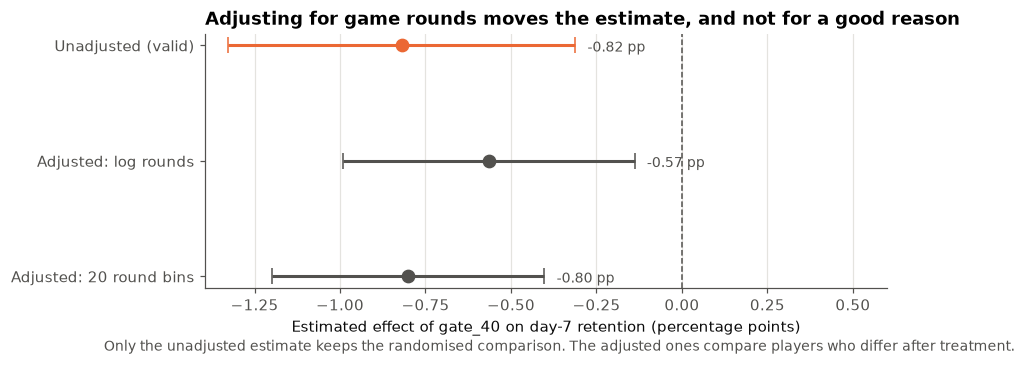

In [21]:
fig, ax = plt.subplots(figsize=(8, 3))
y = np.arange(len(adjusted))[::-1]
for yi, (_, row) in zip(y, adjusted.iterrows()):
    valid = row["model"].startswith("Unadjusted")
    color = COLORS["gate_40"] if valid else INK_MUTED
    ax.errorbar(row["effect_pp"], yi, xerr=[[row["effect_pp"] - row["ci_low_pp"]], [row["ci_high_pp"] - row["effect_pp"]]],
                fmt="o", color=color, markersize=8, capsize=5, elinewidth=2)
    ax.annotate(f"{row['effect_pp']:+.2f} pp", (row["ci_high_pp"], yi), textcoords="offset points",
                xytext=(8, -4), fontsize=9, color=INK_MUTED)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_yticks(y, adjusted["model"])
ax.set_xlabel("Estimated effect of gate_40 on day-7 retention (percentage points)")
ax.set_title("Adjusting for game rounds moves the estimate, and not for a good reason")
ax.grid(axis="y", visible=False)
ax.set_xlim(right=0.6)
fig.text(0.01, -0.08, "Only the unadjusted estimate keeps the randomised comparison. The adjusted ones compare players who differ after treatment.",
         color=INK_MUTED, fontsize=9)
fig.savefig(RESULTS / "post_treatment_adjustment.png")
plt.show()

### Why we don't rely on the adjusted estimate

1. **The gate affects game rounds.** Among players who could reach a gate, gate_30 players stop more often in the 29–59 range, and gate_40 players more often go on to 60+ rounds (chi-square test above). Rounds are an **outcome** of the treatment, not a background characteristic.
2. **Adjusting removes part of the effect we want to measure.** If the gate at 30 changes retention partly *by* changing how much people play, then "holding rounds fixed" removes that pathway. A variable like this is called a **mediator**.
3. **Adjusting compares players who aren't comparable.** A gate_30 player with 45 rounds has already been stopped by a gate and chose to wait or pay. A gate_40 player with 45 rounds may have hit no gate at all, or only just reached one. Randomisation guaranteed comparable *groups*. It says nothing about players who are matched on something that happened *after* assignment.
4. **The answer depends on an arbitrary modelling choice.** Log rounds shrinks the effect to about −0.57 pp. Twenty round bins leave it at about −0.80 pp with a *smaller* p-value. A narrower interval or a smaller p-value can make an adjusted model look "better", but that comes from explaining noise with a variable the treatment itself changed, not from a cleaner comparison.

**Conclusion:** the unadjusted comparison (−0.82 pp, section 3) is the causal estimate the experiment supports. To reduce variance legitimately, we'd need a covariate measured **before** assignment, such as rounds played in the week before the experiment (the CUPED idea). This dataset doesn't have one.

## 6. Export result tables for a Tableau dashboard

These are aggregated results only, with no player-level data. Each file is in long ("tidy") format, which Tableau handles best. Rates and lifts are stored as **fractions** (0.19 = 19%), so Tableau can apply its own % formatting.

In [22]:
EXPORT_NOTE = "exploratory: SRM detected (p=0.0086)"

# 1. Retention rate per group and metric, with 95% Wilson intervals
rate_rows = []
for metric in METRICS:
    for group in ["gate_30", "gate_40"]:
        s = df.loc[df["version"] == group, metric]
        lo, hi = proportion_confint(s.sum(), len(s), method="wilson")
        rate_rows.append({"metric": metric, "version": group, "players": len(s), "retained": int(s.sum()),
                          "retention_rate": s.mean(), "ci_low": lo, "ci_high": hi})
pd.DataFrame(rate_rows).to_csv(RESULTS / "retention_by_group.csv", index=False)

# 2. Main test results (z-test, bootstrap, Holm)
main_export = results[["metric", "n_control", "n_treatment", "rate_control", "rate_treatment", "abs_lift",
                       "ci_low", "ci_high", "rel_lift", "rel_ci_low", "rel_ci_high", "z", "p_value", "p_holm",
                       "significant_after_holm"]].copy()
main_export["metric_role"] = main_export["metric"].map({"retention_7": "primary", "retention_1": "secondary"})
main_export["bootstrap_ci_low"] = main_export["metric"].map(lambda m: boot[m]["ci_low"])
main_export["bootstrap_ci_high"] = main_export["metric"].map(lambda m: boot[m]["ci_high"])
main_export["note"] = EXPORT_NOTE
main_export.to_csv(RESULTS / "main_results.csv", index=False)

# 3. Sensitivity analyses
sensitivity[["analysis", "metric", "n_control", "n_treatment", "rate_control", "rate_treatment",
             "abs_lift", "ci_low", "ci_high", "p_value"]].to_csv(RESULTS / "sensitivity_results.csv", index=False)

# 4. SRM check (overall and by segment)
srm_export = pd.concat([
    pd.DataFrame([{"segment": "All players", "gate_30": counts["gate_30"], "gate_40": counts["gate_40"],
                   "share_gate_40": counts["gate_40"] / counts.sum(), "srm_p_value": srm["p_value"]}]),
    srm_segments,
], ignore_index=True)
srm_export.to_csv(RESULTS / "srm_check.csv", index=False)

# 5. Power / MDE and 6. post-treatment comparison
mde_table.to_csv(RESULTS / "power_mde.csv", index=False)
adjusted.to_csv(RESULTS / "post_treatment_adjustment.csv", index=False)

for f in sorted(RESULTS.glob("*.csv")):
    print(f"{f.name:32s} {len(pd.read_csv(f)):>3d} rows")

main_results.csv                   2 rows
post_treatment_adjustment.csv      3 rows
power_mde.csv                      6 rows
retention_by_group.csv             4 rows
sensitivity_results.csv            8 rows
srm_check.csv                      3 rows
